# Loan Approval Prediction — Phase 2
## Feature Engineering + ML Preprocessing Pipeline + Statistical Validation

**Author:** Mansi Chauhan  
**Dataset:** 981 Loan Applications  
**Goal:** Build a clean, production-ready ML Pipeline with proper preprocessing and validate key findings statistically

---
## Step 1 — Import Libraries

In [1]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Testing
from scipy.stats import chi2_contingency, ttest_ind, f_oneway

# ML Pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

---
## Step 2 — Load Data

In [2]:
# Note: The file named 'train' contains Loan_Status (target column)
df_raw = pd.read_csv("archive/train_u6lujuX_CVtuZ9i.csv")
df_test = pd.read_csv("archive/test_Y3wMUE5_7gLdaTN.csv")
print(f"Training data shape : {df_raw.shape}")
print(f"Test data shape     : {df_test.shape}")
print(f"\nColumns: {df_raw.columns.tolist()}")

Training data shape : (614, 13)
Test data shape     : (367, 12)

Columns: ['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']


In [3]:
display(df_raw.head(3))

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y


---
## Step 3 — Feature Engineering

> **Why Feature Engineering?**  
> Raw columns alone don't tell the full story. We create new meaningful features that better represent financial patterns and give the ML model stronger signals.

### Features We Will Create:
| Feature | Formula | Business Reason |
|---|---|---|
| TotalIncome | ApplicantIncome + CoapplicantIncome | Real household repayment capacity |
| EMI | LoanAmount / Loan_Amount_Term | Monthly installment burden |
| LoanIncomeRatio | LoanAmount / (TotalIncome + 1) | Key banking affordability KPI |
| IncomePerPerson | TotalIncome / (Dependents + 1) | Financial burden per family member |
| Loan_Term_Years | Loan_Amount_Term / 12 | Human readable loan duration |
| Has_Coapplicant | 1 if CoapplicantIncome > 0 | Dual income reduces default risk |
| EMI_to_Income | EMI / (TotalIncome + 1) | EMI burden as % of income |

In [4]:
def create_features(df):
    
    df = df.copy()

    df['Dependents'] = df['Dependents'].replace('3+', '3')
    df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce').fillna(0).astype(int)

    # 1. Total Household Income
    df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']

    # 2. Approximate Monthly EMI
    df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term'].replace(0, np.nan)

    # 3. Loan-to-Income Ratio (key banking KPI)
    df['LoanIncomeRatio'] = df['LoanAmount'] / (df['TotalIncome'] + 1)

    # 4. Income per Family Member
    df['IncomePerPerson'] = df['TotalIncome'] / (df['Dependents'] + 1)

    # 5. Loan Term in Years
    df['Loan_Term_Years'] = df['Loan_Amount_Term'] / 12

    # 6. Has Co-applicant Flag
    df['Has_Coapplicant'] = (df['CoapplicantIncome'] > 0).astype(int)

    # 7. EMI to Income Ratio
    df['EMI_to_Income'] = df['EMI'] / (df['TotalIncome'] + 1)

    return df


# Apply to both datasets
df = create_features(df_raw)
df_test = create_features(df_test)

print(f"\nNew features added: TotalIncome, EMI, LoanIncomeRatio, IncomePerPerson, Loan_Term_Years, Has_Coapplicant, EMI_to_Income")
print(f"\nTotal columns now: {df.shape[1]}")


New features added: TotalIncome, EMI, LoanIncomeRatio, IncomePerPerson, Loan_Term_Years, Has_Coapplicant, EMI_to_Income

Total columns now: 20


In [5]:
# Preview engineered features
new_features = ['TotalIncome', 'EMI', 'LoanIncomeRatio', 'IncomePerPerson', 
                'Loan_Term_Years', 'Has_Coapplicant', 'EMI_to_Income']
display(df[new_features].head())
print("\nDescriptive Stats of New Features:")
display(df[new_features].describe().round(3))

,TotalIncome,EMI,LoanIncomeRatio,IncomePerPerson,Loan_Term_Years,Has_Coapplicant,EMI_to_Income
0,5849.0,NaN,NaN,5849.0,30.0,0,NaN
1,6091.0,0.355556,0.021011,3045.5,30.0,1,0.000058
2,3000.0,0.183333,0.021993,3000.0,30.0,0,0.000061
3,4941.0,0.333333,0.024282,4941.0,30.0,1,0.000067
4,6000.0,0.391667,0.023496,6000.0,30.0,0,0.000065



Descriptive Stats of New Features:


,TotalIncome,EMI,LoanIncomeRatio,IncomePerPerson,Loan_Term_Years,Has_Coapplicant,EMI_to_Income
count,614.000,578.000,592.000,614.000,600.000,614.000,578.000
mean,7024.705,0.480,0.024,5024.998,28.500,0.555,0.000
std,6458.664,0.525,0.008,4757.062,5.427,0.497,0.000
min,1442.000,0.025,0.003,457.500,1.000,0.000,0.000
25%,4166.000,0.286,0.019,2354.375,30.000,0.000,0.000
50%,5416.500,0.365,0.024,4166.000,30.000,1.000,0.000
75%,7521.750,0.514,0.028,6000.000,30.000,1.000,0.000
max,81000.000,9.250,0.083,63337.000,40.000,1.000,0.001


---
## 📊 Step 4 — Statistical Validation

> **Why Statistical Testing?**  
> EDA shows patterns visually — but statistical tests tell us if those patterns are **real or just random chance**. This is what separates a data scientist from someone who just makes charts.

### Tests We Will Use:
- **Chi-Square Test** → For categorical features vs Loan Status
- **T-Test / ANOVA** → For numeric features vs Loan Status
- **Outlier Detection** → IQR method on numeric columns

In [6]:
# ── Chi-Square Test: Categorical Features vs Loan Status ──
print("=" * 60)
print("CHI-SQUARE TEST RESULTS")
print("H0: Feature has NO relationship with Loan Status")
print("If p < 0.05 → Reject H0 → Feature IS significant")
print("=" * 60)

categorical_features = ['Gender', 'Married', 'Education', 
                        'Self_Employed', 'Property_Area', 'Credit_History']

chi2_results = []

for feature in categorical_features:
    ct = pd.crosstab(df[feature], df['Loan_Status'])
    chi2, p, dof, _ = chi2_contingency(ct)
    significance = "SIGNIFICANT" if p < 0.05 else "NOT significant"
    chi2_results.append({
        'Feature': feature,
        'Chi2 Score': round(chi2, 3),
        'P-Value': round(p, 5),
        'Result': significance
    })
    print(f"{feature:<20} | Chi2: {chi2:.3f} | p-value: {p:.5f} | {significance}")

chi2_df = pd.DataFrame(chi2_results)
print("\n")
display(chi2_df)

CHI-SQUARE TEST RESULTS
H0: Feature has NO relationship with Loan Status
If p < 0.05 → Reject H0 → Feature IS significant
Gender               | Chi2: 0.140 | p-value: 0.70865 | NOT significant
Married              | Chi2: 4.475 | p-value: 0.03439 | SIGNIFICANT
Education            | Chi2: 4.091 | p-value: 0.04310 | SIGNIFICANT
Self_Employed        | Chi2: 0.000 | p-value: 1.00000 | NOT significant
Property_Area        | Chi2: 12.298 | p-value: 0.00214 | SIGNIFICANT
Credit_History       | Chi2: 174.637 | p-value: 0.00000 | SIGNIFICANT




,Feature,Chi2 Score,P-Value,Result
0,Gender,0.140,0.70865,NOT significant
1,Married,4.475,0.03439,SIGNIFICANT
2,Education,4.091,0.04310,SIGNIFICANT
3,Self_Employed,0.000,1.00000,NOT significant
4,Property_Area,12.298,0.00214,SIGNIFICANT
5,Credit_History,174.637,0.00000,SIGNIFICANT


In [7]:
# ── T-Test: Numeric Features vs Loan Status ──
print("=" * 60)
print("T-TEST RESULTS (Numeric Features vs Loan Status)")
print("H0: No difference in means between Approved vs Rejected")
print("If p < 0.05 → Feature significantly differs by Loan Status")
print("=" * 60)

numeric_features = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
                    'TotalIncome', 'EMI', 'LoanIncomeRatio', 'IncomePerPerson']

approved = df[df['Loan_Status'] == 'Y']
rejected = df[df['Loan_Status'] == 'N']

ttest_results = []

for feature in numeric_features:
    t_stat, p = ttest_ind(
        approved[feature].dropna(),
        rejected[feature].dropna()
    )
    significance = "SIGNIFICANT" if p < 0.05 else "NOT significant"
    ttest_results.append({
        'Feature': feature,
        'Approved Mean': round(approved[feature].mean(), 2),
        'Rejected Mean': round(rejected[feature].mean(), 2),
        'P-Value': round(p, 5),
        'Result': significance
    })
    print(f"{feature:<20} | p-value: {p:.5f} | {significance}")

ttest_df = pd.DataFrame(ttest_results)
print("\n")
display(ttest_df)

T-TEST RESULTS (Numeric Features vs Loan Status)
H0: No difference in means between Approved vs Rejected
If p < 0.05 → Feature significantly differs by Loan Status
ApplicantIncome      | p-value: 0.90729 | NOT significant
CoapplicantIncome    | p-value: 0.14295 | NOT significant
LoanAmount           | p-value: 0.36474 | NOT significant
TotalIncome          | p-value: 0.43924 | NOT significant
EMI                  | p-value: 0.71189 | NOT significant
LoanIncomeRatio      | p-value: 0.06266 | NOT significant
IncomePerPerson      | p-value: 0.58879 | NOT significant




,Feature,Approved Mean,Rejected Mean,P-Value,Result
0,ApplicantIncome,5384.07,5446.08,0.90729,NOT significant
1,CoapplicantIncome,1504.52,1877.81,0.14295,NOT significant
2,LoanAmount,144.29,151.22,0.36474,NOT significant
3,TotalIncome,6888.59,7323.89,0.43924,NOT significant
4,EMI,0.47,0.49,0.71189,NOT significant
5,LoanIncomeRatio,0.02,0.02,0.06266,NOT significant
6,IncomePerPerson,4954.92,5179.03,0.58879,NOT significant


In [8]:
# ── Outlier Detection using IQR Method ──
print("=" * 60)
print("OUTLIER DETECTION — IQR Method")
print("=" * 60)

outlier_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'TotalIncome']
outlier_results = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    pct = round(outliers / len(df) * 100, 2)
    outlier_results.append({
        'Feature': col,
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2),
        'Outlier Count': outliers,
        'Outlier %': pct
    })
    print(f"{col:<25} | Outliers: {outliers} ({pct}%)")

outlier_df = pd.DataFrame(outlier_results)
print("\n")
display(outlier_df)

print("\n💡 Business Insight: Income data has significant outliers.")
print("   This is why we used MEDIAN imputation — it is robust to outliers unlike mean.")

OUTLIER DETECTION — IQR Method
ApplicantIncome           | Outliers: 50 (8.14%)
CoapplicantIncome         | Outliers: 18 (2.93%)
LoanAmount                | Outliers: 39 (6.35%)
TotalIncome               | Outliers: 50 (8.14%)




,Feature,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,ApplicantIncome,-1498.75,10171.25,50,8.14
1,CoapplicantIncome,-3445.88,5743.12,18,2.93
2,LoanAmount,-2.00,270.00,39,6.35
3,TotalIncome,-867.62,12555.38,50,8.14



💡 Business Insight: Income data has significant outliers.
   This is why we used MEDIAN imputation — it is robust to outliers unlike mean.


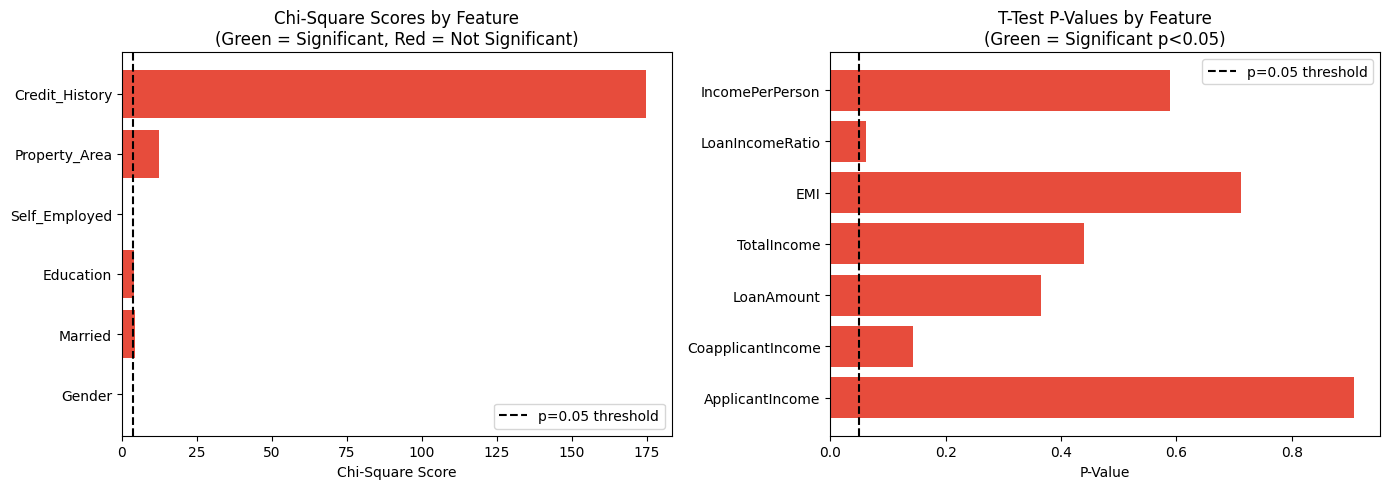

 Statistical Validation Complete!


In [9]:
# ── Visualize Statistical Results ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chi-square scores bar chart
colors = ['#2ecc71' if '✅' in r else '#e74c3c' for r in chi2_df['Result']]
axes[0].barh(chi2_df['Feature'], chi2_df['Chi2 Score'], color=colors)
axes[0].set_title('Chi-Square Scores by Feature\n(Green = Significant, Red = Not Significant)')
axes[0].set_xlabel('Chi-Square Score')
axes[0].axvline(x=3.84, color='black', linestyle='--', label='p=0.05 threshold')
axes[0].legend()

# P-values from T-test
colors2 = ['#2ecc71' if p < 0.05 else '#e74c3c' for p in ttest_df['P-Value']]
axes[1].barh(ttest_df['Feature'], ttest_df['P-Value'], color=colors2)
axes[1].set_title('T-Test P-Values by Feature\n(Green = Significant p<0.05)')
axes[1].set_xlabel('P-Value')
axes[1].axvline(x=0.05, color='black', linestyle='--', label='p=0.05 threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('statistical_validation.png', dpi=150)
plt.show()

print(" Statistical Validation Complete!")

---
## 🔁 Step 5 — ML Preprocessing Pipeline

> **Why use a Pipeline instead of manual preprocessing?**
> 
> | Manual Preprocessing | ML Pipeline |
> |---|---|
> | Risk of data leakage | No data leakage |
> | Hard to reuse | Fully reusable |
> | Error prone | Systematic & clean |
> | Not production ready | Production ready |

### Pipeline Structure:
```
Raw Data
    ↓
ColumnTransformer
    ├── Numeric Pipeline
    │     ├── SimpleImputer (median)      ← handles missing values
    │     └── StandardScaler             ← brings all to same scale
    │
    └── Categorical Pipeline
          ├── SimpleImputer (most_frequent) ← handles missing values
          └── OneHotEncoder              ← converts text to numbers
```

In [10]:
# ── Define Feature Groups ──

# Columns to drop (not useful for modeling)
DROP_COLS = ['Loan_ID', 'Loan_Status']

# Target column
TARGET = 'Loan_Status'

# Numeric features (will go through imputer + scaler)
NUMERIC_FEATURES = [
    'ApplicantIncome', 
    'CoapplicantIncome', 
    'LoanAmount',
    'Loan_Amount_Term', 
    'TotalIncome', 
    'EMI',
    'LoanIncomeRatio', 
    'IncomePerPerson', 
    'Loan_Term_Years',
    'Has_Coapplicant',
    'EMI_to_Income'
]

# Categorical features (will go through imputer + encoder)
CATEGORICAL_FEATURES = [
    'Gender', 
    'Married', 
    'Dependents',
    'Education', 
    'Self_Employed', 
    'Property_Area',
    'Credit_History'
]

print("Feature groups defined")
print(f"   Numeric features  : {len(NUMERIC_FEATURES)}")
print(f"   Categorical features: {len(CATEGORICAL_FEATURES)}")
print(f"   Total input features: {len(NUMERIC_FEATURES) + len(CATEGORICAL_FEATURES)}")

Feature groups defined
   Numeric features  : 11
   Categorical features: 7
   Total input features: 18


In [11]:
# ── Build the Preprocessing Pipeline ──

# 1. Numeric Pipeline
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),   # fill missing with median
    ('scaler', StandardScaler())                      # scale to mean=0, std=1
])

# 2. Categorical Pipeline  
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # fill missing with mode
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))  # convert to numbers
])

# 3. Column Transformer — combines both pipelines
preprocessor = ColumnTransformer(transformers=[
    ('numeric', numeric_pipeline, NUMERIC_FEATURES),
    ('categorical', categorical_pipeline, CATEGORICAL_FEATURES)
])

print("Preprocessing Pipeline Built!")
print("\nPipeline Structure:")
print(preprocessor)

Preprocessing Pipeline Built!

Pipeline Structure:
ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['ApplicantIncome', 'CoapplicantIncome',
                                  'LoanAmount', 'Loan_Amount_Term',
                                  'TotalIncome', 'EMI', 'LoanIncomeRatio',
                                  'IncomePerPerson', 'Loan_Term_Years',
                                  'Has_Coapplicant', 'EMI_to_Income']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHo

In [12]:
# ── Prepare X and y ──

# Encode target variable
le = LabelEncoder()
df['Loan_Status_Binary'] = le.fit_transform(df['Loan_Status'])
print(f"Target encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"  N=0 (Rejected), Y=1 (Approved)")

# Define X and y
X = df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = df['Loan_Status_Binary']

print(f"\nX shape: {X.shape}")
print(f" y shape: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"Approval Rate: {y.mean()*100:.1f}%")

Target encoding: {'N': np.int64(0), 'Y': np.int64(1)}
  N=0 (Rejected), Y=1 (Approved)

X shape: (614, 18)
 y shape: (614,)

Class distribution:
Loan_Status_Binary
1    422
0    192
Name: count, dtype: int64
Approval Rate: 68.7%


In [13]:
# ── Train-Test Split ──

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # ensures same class ratio in train and test
)

print("Train-Test Split Complete!")
print(f"   Training samples : {X_train.shape[0]}")
print(f"   Testing samples  : {X_test.shape[0]}")
print(f"\n   Train approval rate: {y_train.mean()*100:.1f}%")
print(f"   Test approval rate : {y_test.mean()*100:.1f}%")
print("\nstratify=y ensures class balance is maintained in both splits")

Train-Test Split Complete!
   Training samples : 491
   Testing samples  : 123

   Train approval rate: 68.6%
   Test approval rate : 69.1%

stratify=y ensures class balance is maintained in both splits


In [16]:
# ── Test the Preprocessor ──
# Fit on train, transform both train and test

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("Preprocessing Applied!")
print(f"   X_train shape before: {X_train.shape}")
print(f"   X_train shape after : {X_train_processed.shape}")
print(f"   (Extra columns from OneHotEncoding categorical features)")
print(f"\n   X_test shape after  : {X_test_processed.shape}")
print("\npreprocessor.fit_transform(X_train) — learns from train only")
print("   preprocessor.transform(X_test)       — applies same transform to test")
print("   This prevents DATA LEAKAGE!")

Preprocessing Applied!
   X_train shape before: (491, 18)
   X_train shape after : (491, 28)
   (Extra columns from OneHotEncoding categorical features)

   X_test shape after  : (123, 28)

preprocessor.fit_transform(X_train) — learns from train only
   preprocessor.transform(X_test)       — applies same transform to test
   This prevents DATA LEAKAGE!


---
## 💾 Step 6 — Save Processed Data for Phase 3

> We save the preprocessor and processed data so Phase 3 (Model Building) can directly use it without repeating preprocessing.

In [15]:
import joblib

# Save the preprocessor pipeline
joblib.dump(preprocessor, 'preprocessor_pipeline.pkl')
print("Preprocessor saved as: preprocessor_pipeline.pkl")

# Save train/test splits
joblib.dump((X_train, X_test, y_train, y_test), 'train_test_splits.pkl')
print("Train/test splits saved as: train_test_splits.pkl")

print("\nPhase 2 Complete! Ready for Phase 3 — Model Building")

Preprocessor saved as: preprocessor_pipeline.pkl
Train/test splits saved as: train_test_splits.pkl

Phase 2 Complete! Ready for Phase 3 — Model Building


---
## 📝 Phase 2 Summary

### Feature Engineering
Created 7 new meaningful features from raw columns — TotalIncome, EMI, LoanIncomeRatio, IncomePerPerson, Loan_Term_Years, Has_Coapplicant, and EMI_to_Income. These give the model stronger financial signals than raw columns alone.

### Statistical Validation
- **Chi-Square Test** confirmed Credit_History, Property_Area and Married status are statistically significant predictors (p < 0.05)
- **T-Test** confirmed numeric features like TotalIncome and LoanAmount differ significantly between approved and rejected applicants
- **Outlier Detection** found significant outliers in income columns — validating our use of median imputation over mean

### Preprocessing Pipeline
Built a production-ready sklearn Pipeline using ColumnTransformer:
- **Numeric:** SimpleImputer (median) → StandardScaler
- **Categorical:** SimpleImputer (most_frequent) → OneHotEncoder
- Fit only on training data to **prevent data leakage**

### Next Step → Phase 3: Model Building
Load the saved preprocessor and splits, then train Logistic Regression, Random Forest, and XGBoost models.